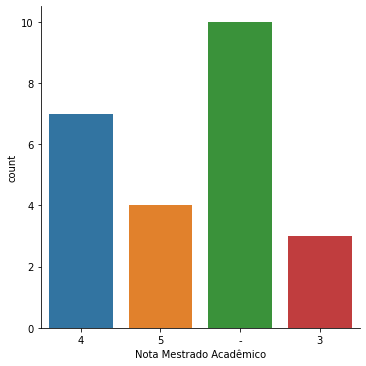

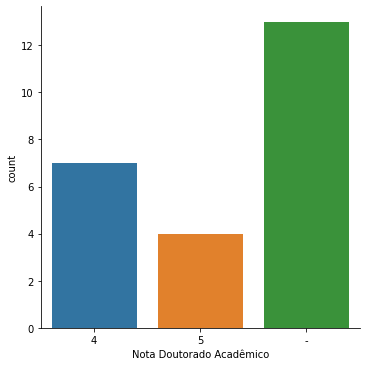

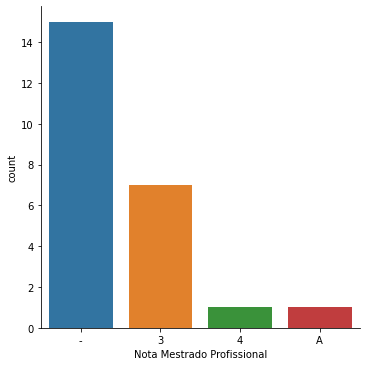

In [1]:
import time
from selenium import webdriver
from selenium.webdriver.firefox.firefox_binary import FirefoxBinary
import requests
import pandas as pd
from bs4 import BeautifulSoup
import seaborn as sns

binary = FirefoxBinary('C:\\Program Files\\Mozilla Firefox\\firefox.exe')
firefox = webdriver.Firefox(firefox_binary=binary, executable_path=r'C:\\geckodriver.exe')

def getNotasByInstituicao():
    try:
        pagina = requests.get(firefox.current_url)
    except Exception as e:
        print(e)
        pagina = requests.get(firefox.current_url)
    conteudo = BeautifulSoup(pagina.content, 'html.parser')
    cursos = list()
    notas_me = list()
    notas_do = list()
    notas_mp = list()
    coordenadores = list()
    areas = list()

    count = 1;

    for celula in conteudo.find_all('td'):
        if(celula.a):
            cursos.append(celula.a.text)
            if(celula.a.get('href')):
                ref = celula.a.get('href')
                idx_i = ref.find(';')
                idx_f = ref.find('?')
                ref = ref[:idx_i] + ref[idx_f:]
                firefox.find_element_by_css_selector(f"a[href*='{ref}']").click()
                time.sleep(5)
                window_name = firefox.window_handles[1]
                firefox.switch_to.window(window_name=window_name)
                try:
                    pagina = requests.get(firefox.current_url)
                except Exception as e:
                    print(e)
                    pagina = requests.get(firefox.current_url)
                conteudo = BeautifulSoup(pagina.content, 'html.parser')
                coordenador = conteudo.find(id='form:nomeCoordenador').getText()
                coordenadores.append(coordenador)
                area = conteudo.find(id='form:codNomeAreaProg').getText()
                areas.append(area)
                firefox.close()
                firefox.switch_to.window(window_name=firefox.window_handles[0])

        if(count % 4 == 0):
            notas_me.append(celula.text.strip())
        if(count % 5 == 0):
            notas_do.append(celula.text.strip())
        if(count % 6 == 0):
            notas_mp.append(celula.text.strip())

        count = count + 1
        if(count > 7):
            count = 1;
    
    firefox.find_element_by_css_selector("a[href*='/sucupira/public/consultas/coleta/programa/quantitativos/quantitativoIes.jsf?areaAvaliacao=0&cdRegiao=3&sgUf=RJ']").click()

    dict = {'Curso': cursos, 'Nota Mestrado Acadêmico': notas_me, 'Nota Doutorado Acadêmico': notas_do, 'Nota Mestrado Profissional': notas_mp, 'Coordenador': coordenadores, 'Área Básica': areas}

    df = pd.DataFrame(dict)

    return df

#firefox = webdriver.Firefox()

firefox.get('https://sucupira.capes.gov.br/sucupira/')

time.sleep(5)
firefox.execute_script("document.getElementsByClassName('block gray')[1].click();")

time.sleep(5)
firefox.find_element_by_css_selector("a[href*='/sucupira/public/consultas/coleta/programa/quantitativos/quantitativoRegiao.jsf']").click()

time.sleep(5)
firefox.find_element_by_css_selector("a[href*='/sucupira/public/consultas/coleta/programa/quantitativos/quantitativoUf.jsf?cdRegiao=3']").click()

time.sleep(5)
firefox.find_element_by_css_selector("a[href*='/sucupira/public/consultas/coleta/programa/quantitativos/quantitativoIes.jsf?cdRegiao=3&sgUf=RJ']").click()

pagina = requests.get(firefox.current_url)
conteudo = BeautifulSoup(pagina.content, 'html.parser')

lista = ['UNIVERSIDADE FEDERAL FLUMINENSE (UFF)', 'UNIVERSIDADE FEDERAL DO RIO DE JANEIRO (UFRJ)', 
         'UNIVERSIDADE FEDERAL DO ESTADO DO RIO DE JANEIRO (UNIRIO)']

resultado_uff = pd.DataFrame()
resultado_ufrj = pd.DataFrame()
resultado_unirio = pd.DataFrame()

for tr in conteudo.find_all('tr')[2:len(conteudo.find_all('tr')) -1]:
    if(tr.td.a.text in lista):
        ref = tr.td.a.get('href')
        idx_i = ref.find(';')
        idx_f = ref.find('?')
        ref = ref[:idx_i] + ref[idx_f:]
        firefox.find_element_by_css_selector(f"a[href*='{ref}']").click()
        time.sleep(5)
        resultado = getNotasByInstituicao()
        
        if(tr.td.a.text == 'UNIVERSIDADE FEDERAL FLUMINENSE (UFF)'):
            resultado_uff = resultado
        if(tr.td.a.text == 'UNIVERSIDADE FEDERAL DO RIO DE JANEIRO (UFRJ)'):
            resultado_ufrj = resultado
        if(tr.td.a.text == 'UNIVERSIDADE FEDERAL DO ESTADO DO RIO DE JANEIRO (UNIRIO)'):
            resultado_unirio = resultado
            
hist_me = sns.catplot(x='Nota Mestrado Acadêmico', kind="count", data=resultado_unirio)
hist_do = sns.catplot(x='Nota Doutorado Acadêmico', kind="count", data=resultado_unirio)
hist_mp = sns.catplot(x='Nota Mestrado Profissional', kind="count", data=resultado_unirio) 

In [2]:
notas_unirio = pd.DataFrame(resultado_unirio[['Nota Mestrado Acadêmico', 'Nota Doutorado Acadêmico', 'Nota Mestrado Profissional']])
notas_unirio['Instituição'] = 'UNIRIO'

notas_ufrj = pd.DataFrame(resultado_ufrj[['Nota Mestrado Acadêmico', 'Nota Doutorado Acadêmico', 'Nota Mestrado Profissional']])
notas_ufrj['Instituição'] = 'UFRJ'

notas_uff = pd.DataFrame(resultado_uff[['Nota Mestrado Acadêmico', 'Nota Doutorado Acadêmico', 'Nota Mestrado Profissional']])
notas_uff['Instituição'] = 'UFF'

notas = notas_unirio.append(notas_ufrj, ignore_index=True)
notas = notas.append(notas_uff, ignore_index=True)

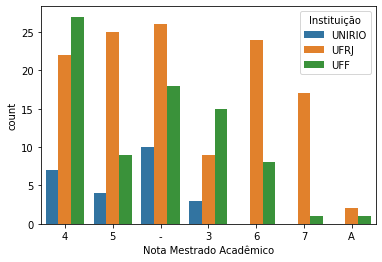

In [3]:
comparativo_me = sns.countplot(x="Nota Mestrado Acadêmico", hue="Instituição", data=notas)

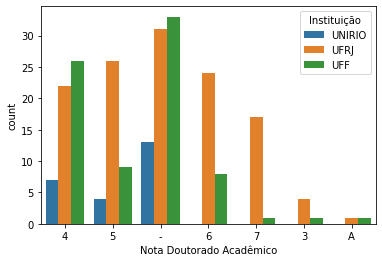

In [4]:
comparativo_do = sns.countplot(x="Nota Doutorado Acadêmico", hue="Instituição", data=notas)

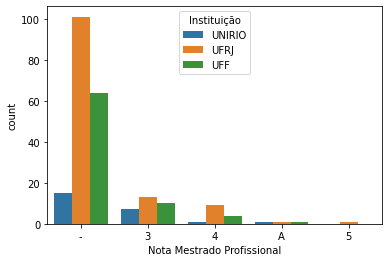

In [5]:
comparativo_mp = sns.countplot(x="Nota Mestrado Profissional", hue="Instituição", data=notas)